In [ ]:
# Paths in this notebook are relative to the repository root; move there when opened from analysis/.
import os
from pathlib import Path
if not Path('Experiments_constraints').is_dir() and (Path('..') / 'Experiments_constraints').is_dir():
    os.chdir('..')
print('CWD:', os.getcwd())

# PLOT only QUANTUM

In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module=r"numpy(\.|$)")

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
import numpy as np
import matplotlib.pyplot as plt
from os import path


In [2]:
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def load_data_wo_constraint(filename, device, quan=False):
    data = torch.load(filename, map_location=device)
    if quan == True:      
        actions = data['actions'].to(torch.float32).to(device)
        response = data['response'].to(torch.float32).to(device)
        true_response = data['true_response'].to(torch.float32)
        num_of_queries =  data['queries']
        eps = data['uncertainty']
        return actions, true_response, response, num_of_queries, eps
    else:
        actions = data['actions'].to(torch.float32).to(device)
        response = data['response'].to(torch.float32).to(device)
        true_response = data['true_response'].to(torch.float32).to(device)
        eps = data['uncertainty']
        num_of_queries = data['queries']
        return actions, true_response, response, num_of_queries, eps
    
def plot_mean_and_CI_with_marker(time_steps, mean, lb, ub, color_mean=None, color_shading=None, marker=None, marker_size=12):
    fill = plt.fill_between(time_steps, ub, lb,
                        color=color_shading, alpha=.2)
    fill = None
    line = plt.plot(time_steps, mean, color_mean, marker=marker, markersize=marker_size, markevery=2000)
    line = line[0]
    return fill, line


q_file  = 'Experiments_constraints/Quantum_Discrete_cUCB/exp_set_1/'
c_file  = 'Experiments_constraints/Classic_Discrete_cUCB/exp_set_1/'
c_acl_file = 'Experiments_constraints/Classic_ACL_Discrete/exp_set_1/'
q_real_file = 'Experiments_constraints/Quantum_Discrete_cUCB_Real/exp_set_1/'
c_unconstrained_file = 'Experiments_constraints/Classic_Discrete_Unconstrained/exp_set_1/'
q_unconstrained_file = 'Experiments_constraints/Quantum_Discrete_Unconstrained/exp_set_1/'
f_max = 0.07159

all_regrets_1 = []   # quantum noise=0.01
all_regrets_2 = []   # classic noise=0.01
all_regrets_3 = []   # quantum noise=0.04
all_regrets_4 = []   # classic noise=0.04
all_regrets_5 = []   # classic ACL noise=0.01
all_regrets_6 = []   # classic ACL noise=0.04

# running-minimum containers
all_runmin_1 = []
all_runmin_2 = []
all_runmin_3 = []
all_runmin_4 = []
all_runmin_5 = []
all_runmin_6 = []

min_len_1 = int(30000+100)
min_len_2 = int(30000+100)
min_len_3 = int(30000+100)
min_len_4 = int(30000+100)
min_len_5 = int(30000+100)
min_len_6 = int(30000+100)

runmin_len_1 = int(30000+100)
runmin_len_2 = int(30000+100)
runmin_len_3 = int(30000+100)
runmin_len_4 = int(30000+100)
runmin_len_5 = int(30000+100)
runmin_len_6 = int(30000+100)

min_01_q = []
min_01_c = []
min_02_q = []
min_02_c = []
min_01_acl = []
min_02_acl = []

all_regrets_8 = []
all_runmin_8 = []
min_len_8 = int(30000+100)
runmin_len_8 = int(30000+100)
min_01_q_real = []

all_regrets_7 = []
all_runmin_7 = []
min_len_7 = int(30000+100)
runmin_len_7 = int(30000+100)
min_02_q_real = []

all_regrets_9 = []   # classic unconstrained noise=0.04
all_runmin_9 = []
min_len_9 = int(30000+100)
runmin_len_9 = int(30000+100)
min_02_cu = []

all_regrets_10 = []  # classic unconstrained noise=0.01
all_runmin_10 = []
min_len_10 = int(30000+100)
runmin_len_10 = int(30000+100)
min_01_cu = []

all_regrets_11 = []  # quantum unconstrained noise=0.01
all_runmin_11 = []
min_len_11 = int(30000+100)
runmin_len_11 = int(30000+100)
min_01_qu = []

all_regrets_12 = []  # quantum unconstrained noise=0.04
all_runmin_12 = []
min_len_12 = int(30000+100)
runmin_len_12 = int(30000+100)
min_02_qu = []

run_list = np.arange(5)
for itr in run_list:
    # ── Quantum, noise=0.01 ──
    obs_noise = 0.1**2
    q_actions_s, q_true_response_s, q_response_s, num_of_queries_s, eps_s = load_data_wo_constraint(q_file + str(obs_noise) + 'quan_training_data_'+ str(itr)+'_.pth', device=device, quan=True)
    values_s = q_true_response_s.detach().cpu().numpy()
    min_01_q.append(min(values_s).item())
    track_queries_s = num_of_queries_s.detach().cpu().numpy().astype(np.int32)
    values_new_s = []
    for ii in range(len(values_s)):
        values_new_s += list(np.repeat(values_s[ii], track_queries_s[ii]))
    values_s = np.array(values_new_s)
    values_s_mae = np.squeeze(values_s)
    values_s_gap = np.abs(f_max - values_s_mae)
    values_acc_s = np.cumsum(values_s_gap)
    min_len_1 = np.min([min_len_1, len(values_acc_s)])
    all_regrets_1.append(values_acc_s)
    values_runmin = np.minimum.accumulate(values_s_mae)
    runmin_len_1 = np.min([runmin_len_1, len(values_runmin)])
    all_runmin_1.append(values_runmin)
    
    # ── Classic, noise=0.01 ──
    obs_noise = 0.1**2
    c_actions, c_true_response, c_response, c_num_of_queries, c_eps = load_data_wo_constraint(c_file + str(obs_noise) + 'training_data_' + str(itr) +'_.pth', device=device)
    c_values = c_true_response.detach().cpu().numpy()
    min_01_c.append(min(c_values).item())
    c_track_queries = c_num_of_queries.detach().cpu().numpy().astype(np.int32)
    c_values_new = []
    for ii in range(len(c_values)):
        c_values_new += list(np.repeat(c_values[ii], c_track_queries[ii]))
    c_values = np.array(c_values_new)
    c_values_mae = np.squeeze(c_values)
    c_values_gap = np.abs(f_max - c_values_mae)
    c_values_acc = np.cumsum(c_values_gap)
    min_len_2 = np.min([min_len_2, len(c_values_acc)])
    all_regrets_2.append(c_values_acc)
    c_values_runmin = np.minimum.accumulate(c_values_mae)
    runmin_len_2 = np.min([runmin_len_2, len(c_values_runmin)])
    all_runmin_2.append(c_values_runmin)
    
    # ── Quantum, noise=0.04 ──
    obs_noise = 0.2**2
    q_actions, q_true_response, q_response, num_of_queries, eps = load_data_wo_constraint(q_file + str(obs_noise) + 'quan_training_data_'+ str(itr)+'_.pth', device=device, quan=True)
    values = q_true_response.detach().cpu().numpy()
    min_02_q.append(min(values).item())
    track_queries = num_of_queries.detach().cpu().numpy().astype(np.int32)
    values_new = []
    for ii in range(len(values)):
        values_new += list(np.repeat(values[ii], track_queries[ii]))
    values = np.array(values_new)
    values_mae = np.squeeze(values)
    values_gap = np.abs(f_max - values_mae)
    values_acc = np.cumsum(values_gap)
    min_len_3 = np.min([min_len_3, len(values_acc)])
    all_regrets_3.append(values_acc)
    values_runmin = np.minimum.accumulate(values_mae)
    runmin_len_3 = np.min([runmin_len_3, len(values_runmin)])
    all_runmin_3.append(values_runmin)
    
    # ── Classic, noise=0.04 ──
    obs_noise = 0.2**2
    c_actions, c_true_response, c_response, c_num_of_queries, c_eps = load_data_wo_constraint(c_file + str(obs_noise) + 'training_data_' + str(itr) +'_.pth', device=device)
    c_values = c_true_response.detach().cpu().numpy()
    min_02_c.append(min(c_values).item())
    c_track_queries = c_num_of_queries.detach().cpu().numpy().astype(np.int32)
    c_values_new = []
    for ii in range(len(c_values)):
        c_values_new += list(np.repeat(c_values[ii], c_track_queries[ii]))
    c_values = np.array(c_values_new)
    c_values_mae = np.squeeze(c_values)
    c_values_gap = np.abs(f_max - c_values_mae)
    c_values_acc = np.cumsum(c_values_gap)
    min_len_4 = np.min([min_len_4, len(c_values_acc)])
    all_regrets_4.append(c_values_acc)
    c_values_runmin = np.minimum.accumulate(c_values_mae)
    runmin_len_4 = np.min([runmin_len_4, len(c_values_runmin)])
    all_runmin_4.append(c_values_runmin)

    # ── Classic ACL, noise=0.01 ──
    obs_noise = 0.1**2
    acl_actions, acl_true_response, acl_response, acl_num_of_queries, acl_eps = load_data_wo_constraint(c_acl_file + str(obs_noise) + 'acl_training_data_' + str(itr) +'_.pth', device=device)
    acl_values = acl_true_response.detach().cpu().numpy()
    min_01_acl.append(min(acl_values).item())
    acl_track_queries = acl_num_of_queries.detach().cpu().numpy().astype(np.int32)
    acl_values_new = []
    for ii in range(len(acl_values)):
        acl_values_new += list(np.repeat(acl_values[ii], acl_track_queries[ii]))
    acl_values = np.array(acl_values_new)
    acl_values_mae = np.squeeze(acl_values)
    acl_values_gap = np.abs(f_max - acl_values_mae)
    acl_values_acc = np.cumsum(acl_values_gap)
    min_len_5 = np.min([min_len_5, len(acl_values_acc)])
    all_regrets_5.append(acl_values_acc)
    acl_values_runmin = np.minimum.accumulate(acl_values_mae)
    runmin_len_5 = np.min([runmin_len_5, len(acl_values_runmin)])
    all_runmin_5.append(acl_values_runmin)

    # ── Classic ACL, noise=0.04 ──
    obs_noise = 0.2**2
    acl_actions, acl_true_response, acl_response, acl_num_of_queries, acl_eps = load_data_wo_constraint(c_acl_file + str(obs_noise) + 'acl_training_data_' + str(itr) +'_.pth', device=device)
    acl_values = acl_true_response.detach().cpu().numpy()
    min_02_acl.append(min(acl_values).item())
    acl_track_queries = acl_num_of_queries.detach().cpu().numpy().astype(np.int32)
    acl_values_new = []
    for ii in range(len(acl_values)):
        acl_values_new += list(np.repeat(acl_values[ii], acl_track_queries[ii]))
    acl_values = np.array(acl_values_new)
    acl_values_mae = np.squeeze(acl_values)
    acl_values_gap = np.abs(f_max - acl_values_mae)
    acl_values_acc = np.cumsum(acl_values_gap)
    min_len_6 = np.min([min_len_6, len(acl_values_acc)])
    all_regrets_6.append(acl_values_acc)
    acl_values_runmin = np.minimum.accumulate(acl_values_mae)
    runmin_len_6 = np.min([runmin_len_6, len(acl_values_runmin)])
    all_runmin_6.append(acl_values_runmin)
    
    # ── Quantum Real, noise=0.01 ──
    obs_noise = 0.1**2
    try:
        q_real_actions, q_real_true_response, q_real_response, q_real_num_of_queries, q_real_eps = load_data_wo_constraint(q_real_file + str(obs_noise) + 'quan_training_data_'+ str(itr)+'_.pth', device=device, quan=True)
        q_real_values = q_real_true_response.detach().cpu().numpy()
        min_01_q_real.append(min(q_real_values).item())
        q_real_track_queries = q_real_num_of_queries.detach().cpu().numpy().astype(np.int32)
        q_real_values_new = []
        for ii in range(len(q_real_values)):
            q_real_values_new += list(np.repeat(q_real_values[ii], q_real_track_queries[ii]))
        q_real_values = np.array(q_real_values_new)
        q_real_values_mae = np.squeeze(q_real_values)
        q_real_values_gap = np.abs(f_max - q_real_values_mae)
        q_real_values_acc = np.cumsum(q_real_values_gap)
        min_len_8 = np.min([min_len_8, len(q_real_values_acc)])
        all_regrets_8.append(q_real_values_acc)
        q_real_values_runmin = np.minimum.accumulate(q_real_values_mae)
        runmin_len_8 = np.min([runmin_len_8, len(q_real_values_runmin)])
        all_runmin_8.append(q_real_values_runmin)
    except Exception as e:
        print(f"Skipping Quantum Real for itr {itr} due to {e}")


    # ── Quantum Real, noise=0.04 ──
    obs_noise = 0.2**2
    try:
        q_real_actions, q_real_true_response, q_real_response, q_real_num_of_queries, q_real_eps = load_data_wo_constraint(q_real_file + str(obs_noise) + 'quan_training_data_'+ str(itr)+'_.pth', device=device, quan=True)
        q_real_values = q_real_true_response.detach().cpu().numpy()
        min_02_q_real.append(min(q_real_values).item())
        q_real_track_queries = q_real_num_of_queries.detach().cpu().numpy().astype(np.int32)
        q_real_values_new = []
        for ii in range(len(q_real_values)):
            q_real_values_new += list(np.repeat(q_real_values[ii], q_real_track_queries[ii]))
        q_real_values = np.array(q_real_values_new)
        q_real_values_mae = np.squeeze(q_real_values)
        q_real_values_gap = np.abs(f_max - q_real_values_mae)
        q_real_values_acc = np.cumsum(q_real_values_gap)
        min_len_7 = np.min([min_len_7, len(q_real_values_acc)])
        all_regrets_7.append(q_real_values_acc)
        q_real_values_runmin = np.minimum.accumulate(q_real_values_mae)
        runmin_len_7 = np.min([runmin_len_7, len(q_real_values_runmin)])
        all_runmin_7.append(q_real_values_runmin)
    except Exception as e:
        print(f"Skipping Quantum Real for itr {itr} due to {e}")

    # ── Classic Unconstrained (filenames may use either str() encoding) ──
    def _resolve_cu_path(noise_tags, itr):
        for _ns in noise_tags:
            _cand = c_unconstrained_file + _ns + 'training_data_' + str(itr) + '_.pth'
            if os.path.exists(_cand):
                return _cand
        return None

    # Classic Unconstrained, noise=0.04 (sigma=0.2)
    try:
        cu_path = _resolve_cu_path([str(0.2**2), '0.04'], itr)
        if cu_path is None:
            raise FileNotFoundError('no sigma=0.2 unconstrained file')
        cu_actions, cu_true_response, cu_response, cu_num_of_queries, cu_eps = load_data_wo_constraint(cu_path, device=device)
        cu_values = cu_true_response.detach().cpu().numpy()
        min_02_cu.append(min(cu_values).item())
        cu_track_queries = cu_num_of_queries.detach().cpu().numpy().astype(np.int32)
        cu_values_new = []
        for ii in range(len(cu_values)):
            cu_values_new += list(np.repeat(cu_values[ii], cu_track_queries[ii]))
        cu_values = np.array(cu_values_new)
        cu_values_mae = np.squeeze(cu_values)
        cu_values_gap = np.abs(f_max - cu_values_mae)
        cu_values_acc = np.cumsum(cu_values_gap)
        min_len_9 = np.min([min_len_9, len(cu_values_acc)])
        all_regrets_9.append(cu_values_acc)
        cu_values_runmin = np.minimum.accumulate(cu_values_mae)
        runmin_len_9 = np.min([runmin_len_9, len(cu_values_runmin)])
        all_runmin_9.append(cu_values_runmin)
    except Exception as e:
        print(f"Skipping Classic Unconstrained (sigma=0.2) for itr {itr} due to {e}")

    # Classic Unconstrained, noise=0.01 (sigma=0.1)
    try:
        cu_path = _resolve_cu_path([str(0.1**2), '0.01'], itr)
        if cu_path is None:
            raise FileNotFoundError('no sigma=0.1 unconstrained file')
        cu_actions, cu_true_response, cu_response, cu_num_of_queries, cu_eps = load_data_wo_constraint(cu_path, device=device)
        cu_values = cu_true_response.detach().cpu().numpy()
        min_01_cu.append(min(cu_values).item())
        cu_track_queries = cu_num_of_queries.detach().cpu().numpy().astype(np.int32)
        cu_values_new = []
        for ii in range(len(cu_values)):
            cu_values_new += list(np.repeat(cu_values[ii], cu_track_queries[ii]))
        cu_values = np.array(cu_values_new)
        cu_values_mae = np.squeeze(cu_values)
        cu_values_gap = np.abs(f_max - cu_values_mae)
        cu_values_acc = np.cumsum(cu_values_gap)
        min_len_10 = np.min([min_len_10, len(cu_values_acc)])
        all_regrets_10.append(cu_values_acc)
        cu_values_runmin = np.minimum.accumulate(cu_values_mae)
        runmin_len_10 = np.min([runmin_len_10, len(cu_values_runmin)])
        all_runmin_10.append(cu_values_runmin)
    except Exception as e:
        print(f"Skipping Classic Unconstrained (sigma=0.1) for itr {itr} due to {e}")

    # Quantum Unconstrained, noise=0.01 (sigma=0.1)
    obs_noise = 0.1**2
    try:
        qu_actions, qu_true_response, qu_response, qu_num_of_queries, qu_eps = load_data_wo_constraint(q_unconstrained_file + str(obs_noise) + 'quan_training_data_' + str(itr) +'_.pth', device=device, quan=True)
        qu_values = qu_true_response.detach().cpu().numpy()
        min_01_qu.append(min(qu_values).item())
        qu_track_queries = qu_num_of_queries.detach().cpu().numpy().astype(np.int32)
        qu_values_new = []
        for ii in range(len(qu_values)):
            qu_values_new += list(np.repeat(qu_values[ii], qu_track_queries[ii]))
        qu_values = np.array(qu_values_new)
        qu_values_mae = np.squeeze(qu_values)
        qu_values_gap = np.abs(f_max - qu_values_mae)
        qu_values_acc = np.cumsum(qu_values_gap)
        min_len_11 = np.min([min_len_11, len(qu_values_acc)])
        all_regrets_11.append(qu_values_acc)
        qu_values_runmin = np.minimum.accumulate(qu_values_mae)
        runmin_len_11 = np.min([runmin_len_11, len(qu_values_runmin)])
        all_runmin_11.append(qu_values_runmin)
    except Exception as e:
        print(f"Skipping Quantum Unconstrained (sigma=0.1) for itr {itr} due to {e}")

    # Quantum Unconstrained, noise=0.04 (sigma=0.2)
    obs_noise = 0.2**2
    try:
        qu_actions, qu_true_response, qu_response, qu_num_of_queries, qu_eps = load_data_wo_constraint(q_unconstrained_file + str(obs_noise) + 'quan_training_data_' + str(itr) +'_.pth', device=device, quan=True)
        qu_values = qu_true_response.detach().cpu().numpy()
        min_02_qu.append(min(qu_values).item())
        qu_track_queries = qu_num_of_queries.detach().cpu().numpy().astype(np.int32)
        qu_values_new = []
        for ii in range(len(qu_values)):
            qu_values_new += list(np.repeat(qu_values[ii], qu_track_queries[ii]))
        qu_values = np.array(qu_values_new)
        qu_values_mae = np.squeeze(qu_values)
        qu_values_gap = np.abs(f_max - qu_values_mae)
        qu_values_acc = np.cumsum(qu_values_gap)
        min_len_12 = np.min([min_len_12, len(qu_values_acc)])
        all_regrets_12.append(qu_values_acc)
        qu_values_runmin = np.minimum.accumulate(qu_values_mae)
        runmin_len_12 = np.min([runmin_len_12, len(qu_values_runmin)])
        all_runmin_12.append(qu_values_runmin)
    except Exception as e:
        print(f"Skipping Quantum Unconstrained (sigma=0.2) for itr {itr} due to {e}")

def report_noise_free_minima(label, minima, target=0.0716, atol=5e-4):
    vals = np.array(minima, dtype=float)
    if vals.size == 0:
        print(f"[Noise-free] {label}: no runs")
        return
    hits = int(np.sum(np.abs(vals - target) <= atol))
    print(
        f"[Noise-free] {label}: mean={vals.mean():.6f}, std={vals.std():.6f}, "
        f"best={vals.min():.6f}, worst={vals.max():.6f}, "
        f"hits@{target:.4f}={hits}/{vals.size} (atol={atol:g})"
    )
    print(f"  per-run minima: {np.round(vals, 6)}")

report_noise_free_minima('Q-Safe BO (σ=0.1)', min_01_q)
report_noise_free_minima('Q-Safe BO (σ=0.2)', min_02_q)
report_noise_free_minima('C-Safe BO (σ=0.1)', min_01_c)
report_noise_free_minima('C-Safe BO (σ=0.2)', min_02_c)
report_noise_free_minima('BO-ACL (σ=0.1)', min_01_acl)
report_noise_free_minima('BO-ACL (σ=0.2)', min_02_acl)
report_noise_free_minima('Q-Safe BO (Real) (σ=0.1)', min_01_q_real)
report_noise_free_minima('Q-Safe BO (Real) (σ=0.2)', min_02_q_real)
report_noise_free_minima('C-Unconstrained (σ=0.1)', min_01_cu)
report_noise_free_minima('C-Unconstrained (σ=0.2)', min_02_cu)
report_noise_free_minima('Q-Unconstrained (σ=0.1)', min_01_qu)
report_noise_free_minima('Q-Unconstrained (σ=0.2)', min_02_qu)



[Noise-free] Q-Safe BO (σ=0.1): mean=0.071591, std=0.000000, best=0.071591, worst=0.071591, hits@0.0716=5/5 (atol=0.0005)
  per-run minima: [0.071591 0.071591 0.071591 0.071591 0.071591]
[Noise-free] Q-Safe BO (σ=0.2): mean=0.071591, std=0.000000, best=0.071591, worst=0.071591, hits@0.0716=5/5 (atol=0.0005)
  per-run minima: [0.071591 0.071591 0.071591 0.071591 0.071591]
[Noise-free] C-Safe BO (σ=0.1): mean=0.071591, std=0.000000, best=0.071591, worst=0.071591, hits@0.0716=5/5 (atol=0.0005)
  per-run minima: [0.071591 0.071591 0.071591 0.071591 0.071591]
[Noise-free] C-Safe BO (σ=0.2): mean=0.071591, std=0.000000, best=0.071591, worst=0.071591, hits@0.0716=5/5 (atol=0.0005)
  per-run minima: [0.071591 0.071591 0.071591 0.071591 0.071591]
[Noise-free] BO-ACL (σ=0.1): mean=0.082429, std=0.013866, best=0.071591, worst=0.108134, hits@0.0716=2/5 (atol=0.0005)
  per-run minima: [0.085781 0.071591 0.108134 0.071591 0.075046]
[Noise-free] BO-ACL (σ=0.2): mean=0.079675, std=0.006613, best=0.071

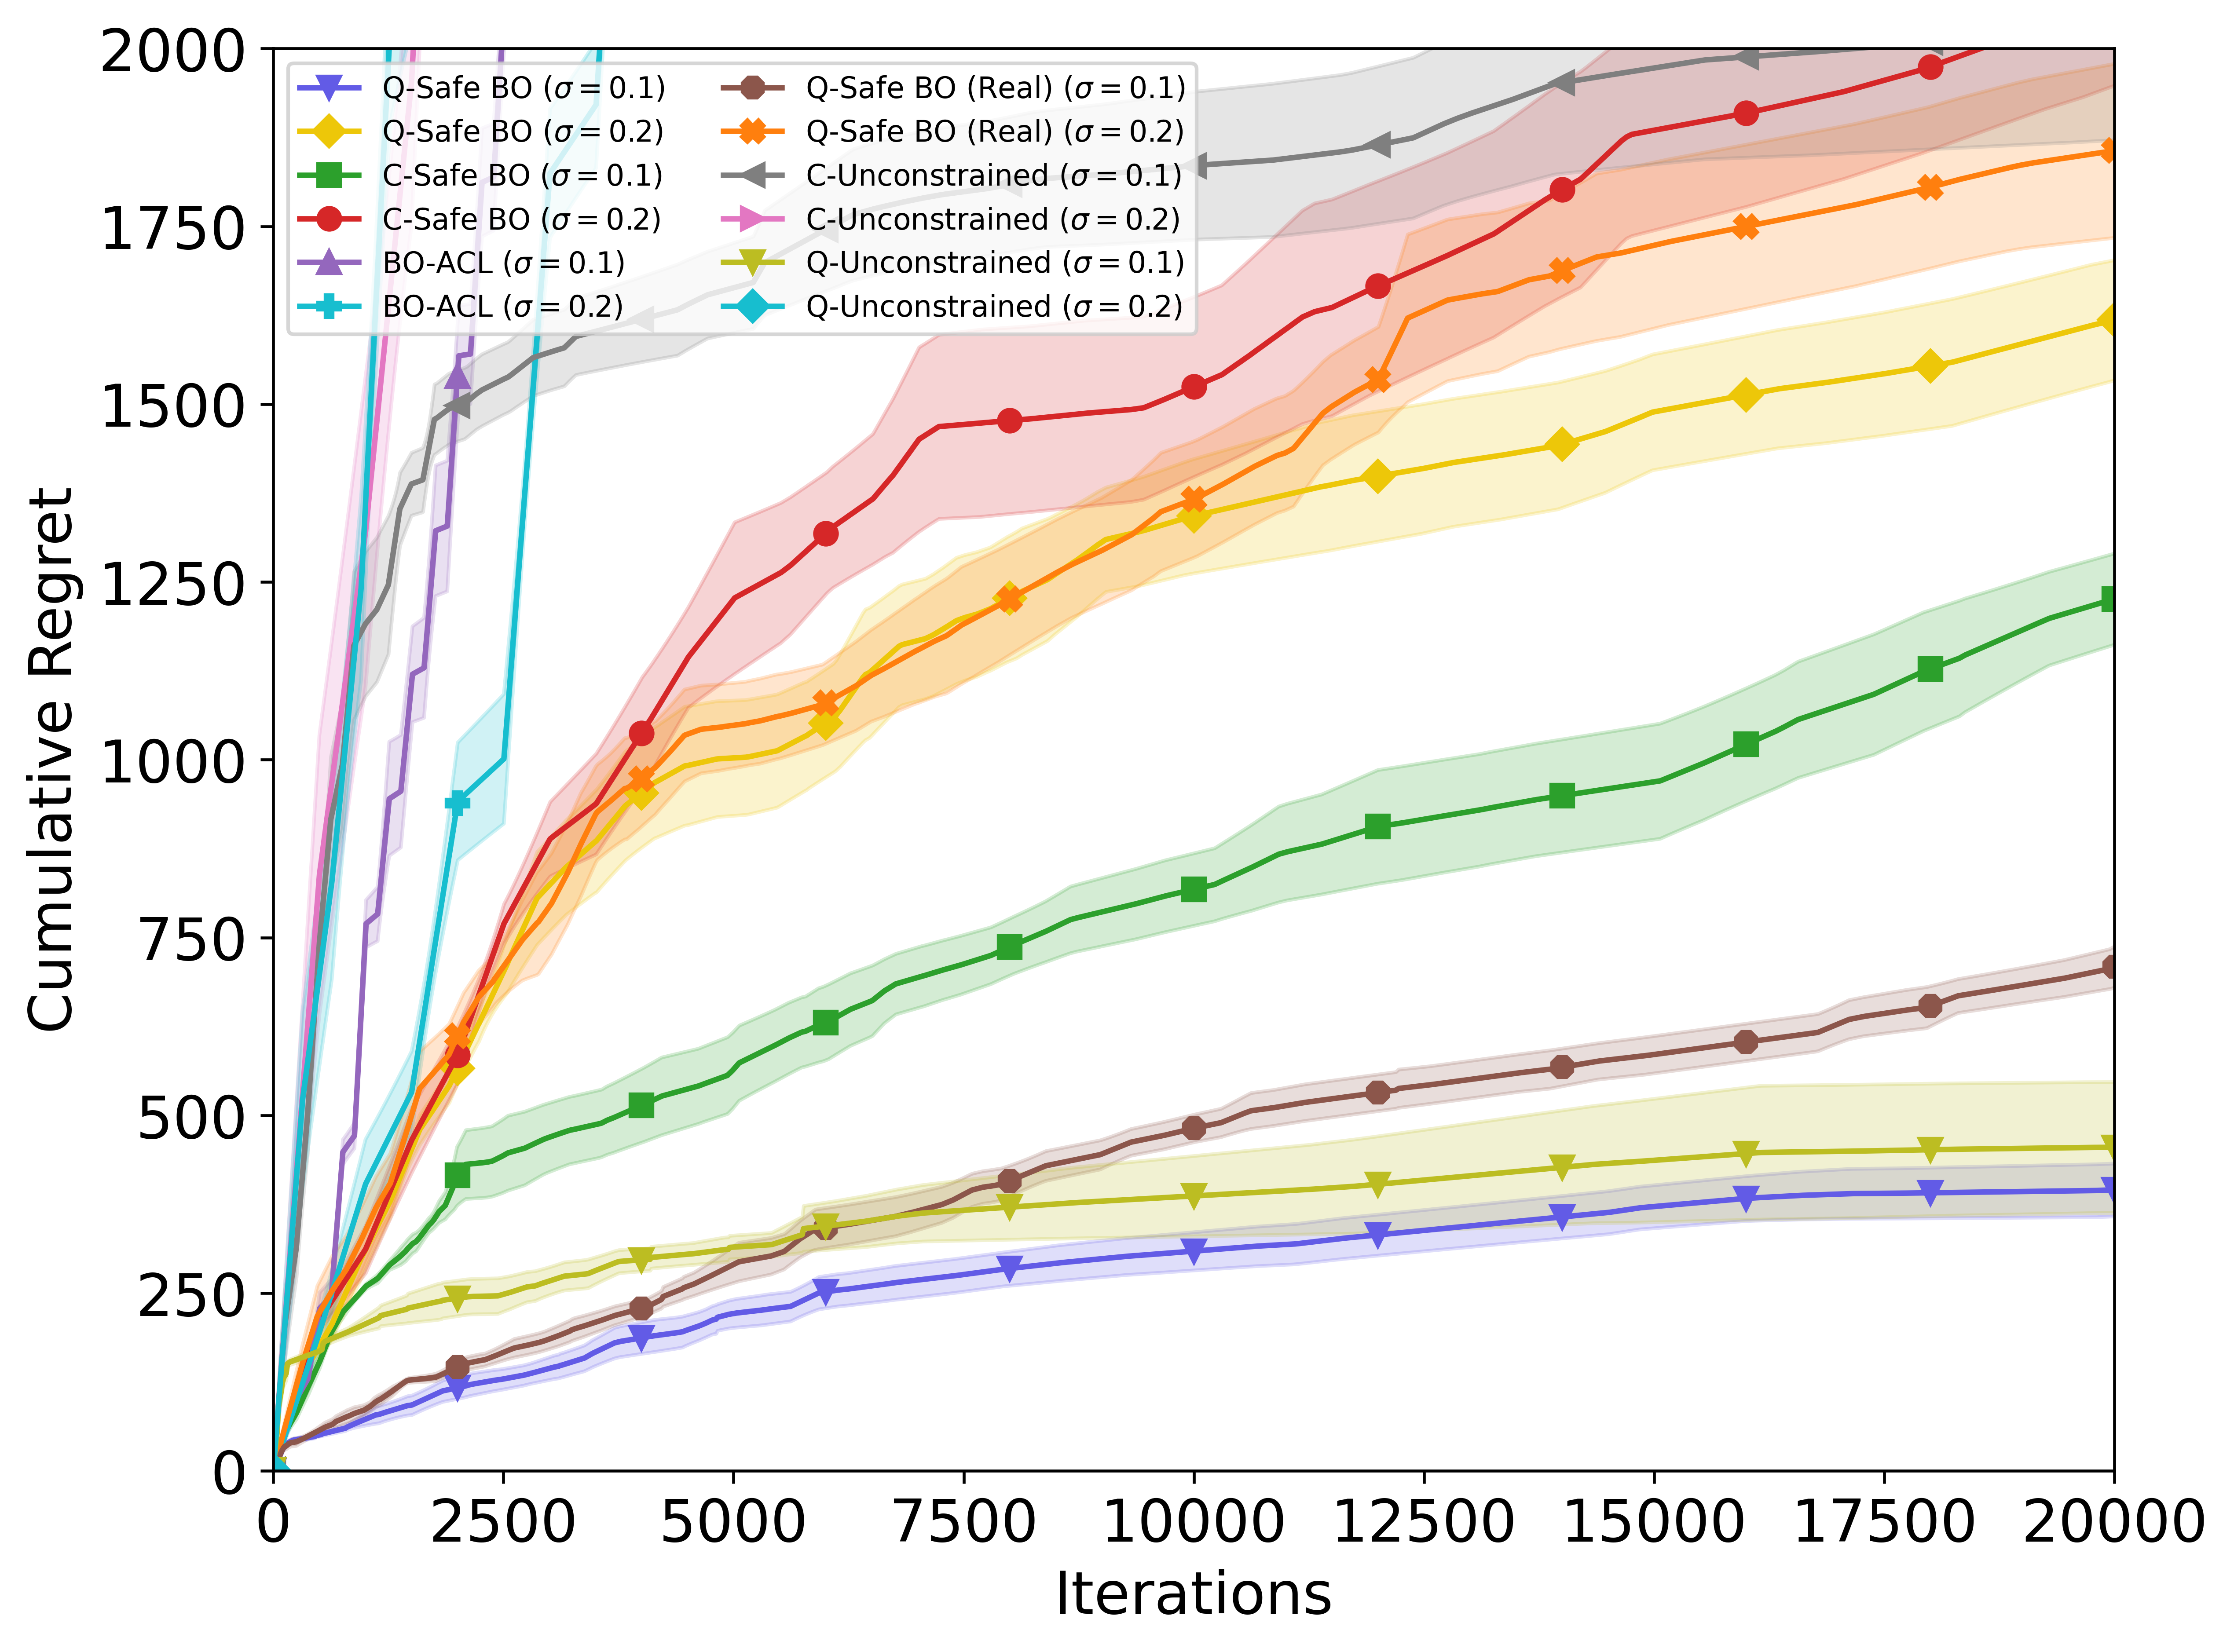

In [3]:
lw = 2.0
plt.rc('font', size=16)
# high-res on screen + save
plt.rcParams['figure.dpi'] = 600     # notebook/interactive
plt.rcParams['savefig.dpi'] = 600     # file output
plt.figure(figsize=(9, 7))

all_regrets_1 = [a[:min_len_1] for a in all_regrets_1]
all_regrets_1_np = np.array(all_regrets_1)
all_regrets_1_np_mean = np.mean(all_regrets_1_np, axis=0)
all_regrets_1_np_stderr = np.std(all_regrets_1_np, axis=0) / np.sqrt(len(run_list))
all_regrets_1_np_ub = all_regrets_1_np_mean + all_regrets_1_np_stderr
all_regrets_1_np_lb = all_regrets_1_np_mean - all_regrets_1_np_stderr

all_regrets_2 = [a[:min_len_2] for a in all_regrets_2]
all_regrets_2_np = np.array(all_regrets_2)
all_regrets_2_np_mean = np.mean(all_regrets_2_np, axis=0)
all_regrets_2_np_stderr = np.std(all_regrets_2_np, axis=0) / np.sqrt(len(run_list))
all_regrets_2_np_ub = all_regrets_2_np_mean + all_regrets_2_np_stderr
all_regrets_2_np_lb = all_regrets_2_np_mean - all_regrets_2_np_stderr

all_regrets_3 = [a[:min_len_3] for a in all_regrets_3]
all_regrets_3_np = np.array(all_regrets_3)
all_regrets_3_np_mean = np.mean(all_regrets_3_np, axis=0)
all_regrets_3_np_stderr = np.std(all_regrets_3_np, axis=0) / np.sqrt(len(run_list))
all_regrets_3_np_ub = all_regrets_3_np_mean + all_regrets_3_np_stderr
all_regrets_3_np_lb = all_regrets_3_np_mean - all_regrets_3_np_stderr

all_regrets_4 = [a[:min_len_4] for a in all_regrets_4]
all_regrets_4_np = np.array(all_regrets_4)
all_regrets_4_np_mean = np.mean(all_regrets_4_np, axis=0)
all_regrets_4_np_stderr = np.std(all_regrets_4_np, axis=0) / np.sqrt(len(run_list))
all_regrets_4_np_ub = all_regrets_4_np_mean + all_regrets_4_np_stderr
all_regrets_4_np_lb = all_regrets_4_np_mean - all_regrets_4_np_stderr

all_regrets_5 = [a[:min_len_5] for a in all_regrets_5]
all_regrets_5_np = np.array(all_regrets_5)
all_regrets_5_np_mean = np.mean(all_regrets_5_np, axis=0)
all_regrets_5_np_stderr = np.std(all_regrets_5_np, axis=0) / np.sqrt(len(run_list))
all_regrets_5_np_ub = all_regrets_5_np_mean + all_regrets_5_np_stderr
all_regrets_5_np_lb = all_regrets_5_np_mean - all_regrets_5_np_stderr

all_regrets_6 = [a[:min_len_6] for a in all_regrets_6]
all_regrets_6_np = np.array(all_regrets_6)
all_regrets_6_np_mean = np.mean(all_regrets_6_np, axis=0)
all_regrets_6_np_stderr = np.std(all_regrets_6_np, axis=0) / np.sqrt(len(run_list))
all_regrets_6_np_ub = all_regrets_6_np_mean + all_regrets_6_np_stderr
all_regrets_6_np_lb = all_regrets_6_np_mean - all_regrets_6_np_stderr


all_regrets_7 = [a[:min_len_7] for a in all_regrets_7]
all_regrets_7_np = np.array(all_regrets_7)
all_regrets_7_np_mean = np.mean(all_regrets_7_np, axis=0)
all_regrets_7_np_stderr = np.std(all_regrets_7_np, axis=0) / np.sqrt(max(1, len(all_regrets_7_np)))
all_regrets_7_np_ub = all_regrets_7_np_mean + all_regrets_7_np_stderr
all_regrets_7_np_lb = all_regrets_7_np_mean - all_regrets_7_np_stderr

all_regrets_8 = [a[:min_len_8] for a in all_regrets_8]
all_regrets_8_np = np.array(all_regrets_8)
all_regrets_8_np_mean = np.mean(all_regrets_8_np, axis=0)
all_regrets_8_np_stderr = np.std(all_regrets_8_np, axis=0) / np.sqrt(max(1, len(all_regrets_8_np)))
all_regrets_8_np_ub = all_regrets_8_np_mean + all_regrets_8_np_stderr
all_regrets_8_np_lb = all_regrets_8_np_mean - all_regrets_8_np_stderr

all_regrets_9 = [a[:min_len_9] for a in all_regrets_9]
all_regrets_9_np = np.array(all_regrets_9)
all_regrets_9_np_mean = np.mean(all_regrets_9_np, axis=0)
all_regrets_9_np_stderr = np.std(all_regrets_9_np, axis=0) / np.sqrt(max(1, len(all_regrets_9_np)))
all_regrets_9_np_ub = all_regrets_9_np_mean + all_regrets_9_np_stderr
all_regrets_9_np_lb = all_regrets_9_np_mean - all_regrets_9_np_stderr
all_regrets_10 = [a[:min_len_10] for a in all_regrets_10]
all_regrets_10_np = np.array(all_regrets_10)
all_regrets_10_np_mean = np.mean(all_regrets_10_np, axis=0)
all_regrets_10_np_stderr = np.std(all_regrets_10_np, axis=0) / np.sqrt(max(1, len(all_regrets_10_np)))
all_regrets_10_np_ub = all_regrets_10_np_mean + all_regrets_10_np_stderr
all_regrets_10_np_lb = all_regrets_10_np_mean - all_regrets_10_np_stderr
all_regrets_11 = [a[:min_len_11] for a in all_regrets_11]
all_regrets_11_np = np.array(all_regrets_11)
all_regrets_11_np_mean = np.mean(all_regrets_11_np, axis=0)
all_regrets_11_np_stderr = np.std(all_regrets_11_np, axis=0) / np.sqrt(max(1, len(all_regrets_11_np)))
all_regrets_11_np_ub = all_regrets_11_np_mean + all_regrets_11_np_stderr
all_regrets_11_np_lb = all_regrets_11_np_mean - all_regrets_11_np_stderr
all_regrets_12 = [a[:min_len_12] for a in all_regrets_12]
all_regrets_12_np = np.array(all_regrets_12)
all_regrets_12_np_mean = np.mean(all_regrets_12_np, axis=0)
all_regrets_12_np_stderr = np.std(all_regrets_12_np, axis=0) / np.sqrt(max(1, len(all_regrets_12_np)))
all_regrets_12_np_ub = all_regrets_12_np_mean + all_regrets_12_np_stderr
all_regrets_12_np_lb = all_regrets_12_np_mean - all_regrets_12_np_stderr

color_list = ["#625be6", "#edc709", '#2ca02c', '#d62728', '#9467bd', '#17becf', '#ff7f0e', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'] 
marker_list = ["v", "D", "s", "o", "^", "P", "X", "8", ">", "<", "v", "D"]
inds = np.arange(1, 1e6+1)
marker_size = 6

fill1, line1 = plot_mean_and_CI_with_marker(inds[:min_len_1], all_regrets_1_np_mean[:min_len_1], all_regrets_1_np_ub[:min_len_1], all_regrets_1_np_lb[:min_len_1], color_mean=color_list[0], color_shading=color_list[0], marker=marker_list[0], marker_size=marker_size)
fill2, line2 = plot_mean_and_CI_with_marker(inds[:min_len_2], all_regrets_2_np_mean[:min_len_2], all_regrets_2_np_ub[:min_len_2], all_regrets_2_np_lb[:min_len_2], color_mean=color_list[2], color_shading=color_list[2], marker=marker_list[2], marker_size=marker_size)
fill3, line3 = plot_mean_and_CI_with_marker(inds[:min_len_3], all_regrets_3_np_mean[:min_len_3], all_regrets_3_np_ub[:min_len_3], all_regrets_3_np_lb[:min_len_3], color_mean=color_list[1], color_shading=color_list[1], marker=marker_list[1], marker_size=marker_size)
fill4, line4 = plot_mean_and_CI_with_marker(inds[:min_len_4], all_regrets_4_np_mean[:min_len_4], all_regrets_4_np_ub[:min_len_4], all_regrets_4_np_lb[:min_len_4], color_mean=color_list[3], color_shading=color_list[3], marker=marker_list[3], marker_size=marker_size)
fill5, line5 = plot_mean_and_CI_with_marker(inds[:min_len_5], all_regrets_5_np_mean[:min_len_5], all_regrets_5_np_ub[:min_len_5], all_regrets_5_np_lb[:min_len_5], color_mean=color_list[4], color_shading=color_list[4], marker=marker_list[4], marker_size=marker_size)
fill6, line6 = plot_mean_and_CI_with_marker(inds[:min_len_6], all_regrets_6_np_mean[:min_len_6], all_regrets_6_np_ub[:min_len_6], all_regrets_6_np_lb[:min_len_6], color_mean=color_list[5], color_shading=color_list[5], marker=marker_list[5], marker_size=marker_size)
fill7, line7 = plot_mean_and_CI_with_marker(inds[:min_len_7], all_regrets_7_np_mean[:min_len_7], all_regrets_7_np_ub[:min_len_7], all_regrets_7_np_lb[:min_len_7], color_mean=color_list[6], color_shading=color_list[6], marker=marker_list[6], marker_size=marker_size)
fill8, line8 = plot_mean_and_CI_with_marker(inds[:min_len_8], all_regrets_8_np_mean[:min_len_8], all_regrets_8_np_ub[:min_len_8], all_regrets_8_np_lb[:min_len_8], color_mean=color_list[7], color_shading=color_list[7], marker=marker_list[7], marker_size=marker_size)
fill9, line9 = plot_mean_and_CI_with_marker(inds[:min_len_9], all_regrets_9_np_mean[:min_len_9], all_regrets_9_np_ub[:min_len_9], all_regrets_9_np_lb[:min_len_9], color_mean=color_list[8], color_shading=color_list[8], marker=marker_list[8], marker_size=marker_size)
fill10, line10 = plot_mean_and_CI_with_marker(inds[:min_len_10], all_regrets_10_np_mean[:min_len_10], all_regrets_10_np_ub[:min_len_10], all_regrets_10_np_lb[:min_len_10], color_mean=color_list[9], color_shading=color_list[9], marker=marker_list[9], marker_size=marker_size)
fill11, line11 = plot_mean_and_CI_with_marker(inds[:min_len_11], all_regrets_11_np_mean[:min_len_11], all_regrets_11_np_ub[:min_len_11], all_regrets_11_np_lb[:min_len_11], color_mean=color_list[10], color_shading=color_list[10], marker=marker_list[10], marker_size=marker_size)
fill12, line12 = plot_mean_and_CI_with_marker(inds[:min_len_12], all_regrets_12_np_mean[:min_len_12], all_regrets_12_np_ub[:min_len_12], all_regrets_12_np_lb[:min_len_12], color_mean=color_list[11], color_shading=color_list[11], marker=marker_list[11], marker_size=marker_size)

plt.legend([line1, line3, line2, line4, line5, line6, line8, line7, line10, line9, line11, line12],
    ["Q-Safe BO ($\sigma=0.1$)", "Q-Safe BO ($\sigma=0.2$)",
     "C-Safe BO ($\sigma=0.1$)", "C-Safe BO ($\sigma=0.2$)",
     "BO-ACL ($\sigma=0.1$)", "BO-ACL ($\sigma=0.2$)", "Q-Safe BO (Real) ($\sigma=0.1$)", "Q-Safe BO (Real) ($\sigma=0.2$)", "C-Unconstrained ($\sigma=0.1$)", "C-Unconstrained ($\sigma=0.2$)", "Q-Unconstrained ($\sigma=0.1$)", "Q-Unconstrained ($\sigma=0.2$)"],
    prop={'size':8}, ncol=2)

axes = plt.gca()
axes.set_xlim([0, 20000])
axes.set_ylim([0, 2000])
plt.ylabel("Cumulative Regret")
plt.xlabel("Iterations")

plt.savefig('figures/discrete_cumulative_regret.png', bbox_inches='tight')


[RunMin] Q-Safe BO (σ=0.1): final mean=0.071591, std=0.000000, min=0.071591, max=0.071591, hits@0.0716=5/5 (atol=0.0005), monotonic=True
[RunMin] Q-Safe BO (σ=0.2): final mean=0.071591, std=0.000000, min=0.071591, max=0.071591, hits@0.0716=5/5 (atol=0.0005), monotonic=True
[RunMin] C-Safe BO (σ=0.1): final mean=0.071591, std=0.000000, min=0.071591, max=0.071591, hits@0.0716=5/5 (atol=0.0005), monotonic=True
[RunMin] C-Safe BO (σ=0.2): final mean=0.071591, std=0.000000, min=0.071591, max=0.071591, hits@0.0716=5/5 (atol=0.0005), monotonic=True
[RunMin] BO-ACL (σ=0.1): final mean=0.082429, std=0.013866, min=0.071591, max=0.108134, hits@0.0716=2/5 (atol=0.0005), monotonic=True
[RunMin] BO-ACL (σ=0.2): final mean=0.079675, std=0.006613, min=0.071591, max=0.089011, hits@0.0716=1/5 (atol=0.0005), monotonic=True
[RunMin] Q-Safe BO (Real) (σ=0.2): final mean=0.071591, std=0.000000, min=0.071591, max=0.071591, hits@0.0716=5/5 (atol=0.0005), monotonic=True
[RunMin] Q-Safe BO (Real) (σ=0.1): final

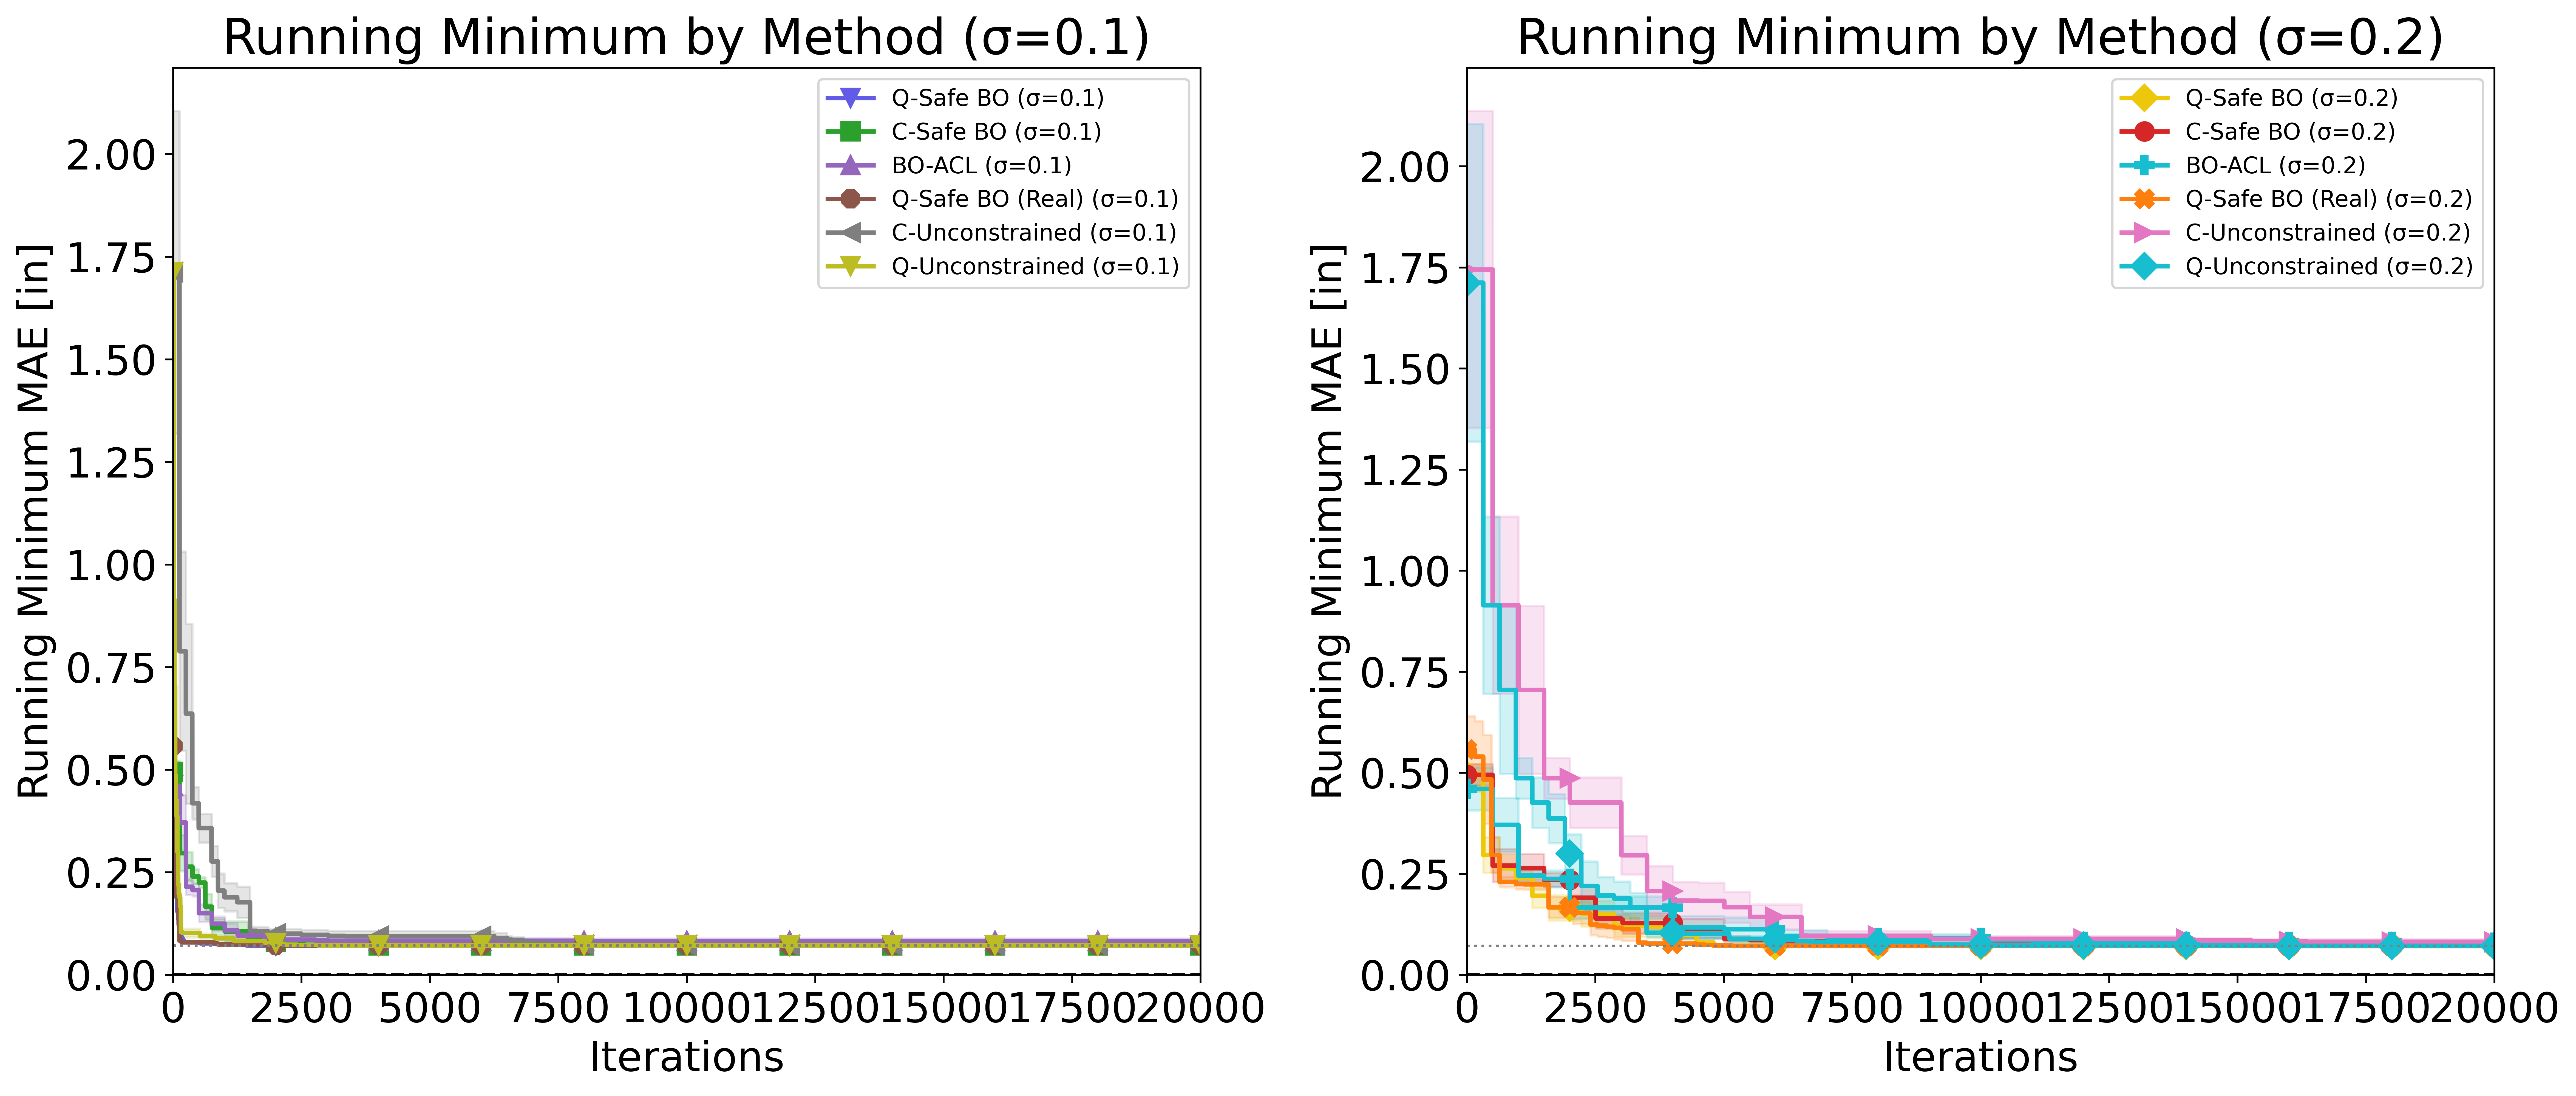

In [4]:
lw = 2.0
plt.rc('font', size=18)
plt.rcParams['figure.dpi'] = 600
plt.rcParams['savefig.dpi'] = 600


def summarize_series(series, trim_len):
    series_t = [np.asarray(a[:trim_len], dtype=float) for a in series if len(a) > 0]
    if len(series_t) == 0:
        return None
    arr = np.array(series_t)
    mean = np.mean(arr, axis=0)
    stderr = np.std(arr, axis=0) / np.sqrt(len(series_t))
    ub = mean + stderr
    lb = mean - stderr
    return {
        "mean": mean,
        "ub": ub,
        "lb": lb,
        "n": len(series_t),
    }


def plot_runmin_panel(ax, curves, title, marker_size=8):
    inds = np.arange(1, 1_000_000 + 1)
    plotted = []

    for cfg in curves:
        stats = summarize_series(cfg["series"], cfg["trim_len"])
        if stats is None:
            continue
        x = inds[: cfg["trim_len"]]
        ax.fill_between(x, stats["ub"], stats["lb"], color=cfg["color"], alpha=0.2)
        (line,) = ax.plot(
            x,
            stats["mean"],
            color=cfg["color"],
            marker=cfg["marker"],
            markersize=marker_size,
            markevery=2000,
            linewidth=lw,
        )
        plotted.append((line, cfg["label"], stats))

    ax.set_xlim([0, 20000])
    if plotted:
        y_top = max(float(np.nanmax(item[2]["ub"])) for item in plotted)
    else:
        y_top = 0.25
    ax.set_ylim([0.0, max(0.25, 1.05 * y_top)])

    ax.set_title(title)
    ax.set_ylabel("Running Minimum MAE [in]")
    ax.set_xlabel("Iterations")
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
    ax.axhline(y=0.0716, color='gray', linestyle=':', linewidth=1.2)

    if plotted:
        ax.legend(
            [item[0] for item in plotted],
            [item[1] for item in plotted],
            prop={'size':10},
            ncol=1,
            loc='upper right',
        )


def summarize_runmin(name, series, target=0.0716, atol=5e-4):
    finals = [float(s[-1]) for s in series if len(s) > 0]
    monotonic = all(np.all(np.diff(np.asarray(s, dtype=float)) <= 1e-12) for s in series if len(s) > 1)
    if len(finals) == 0:
        print(f"[RunMin] {name}: no runs")
        return
    finals_np = np.array(finals, dtype=float)
    hits = int(np.sum(np.abs(finals_np - target) <= atol))
    print(
        f"[RunMin] {name}: final mean={finals_np.mean():.6f}, std={finals_np.std():.6f}, "
        f"min={finals_np.min():.6f}, max={finals_np.max():.6f}, "
        f"hits@{target:.4f}={hits}/{finals_np.size} (atol={atol:g}), monotonic={monotonic}"
    )


color_list = ["#625be6", "#edc709", '#2ca02c', '#d62728', '#9467bd', '#17becf', '#ff7f0e', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
marker_list = ["v", "D", "s", "o", "^", "P", "X", "8", ">", "<", "v", "D"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

curves_sigma_01 = [
    {"series": all_runmin_1, "trim_len": runmin_len_1, "label": "Q-Safe BO (σ=0.1)", "color": color_list[0], "marker": marker_list[0]},
    {"series": all_runmin_2, "trim_len": runmin_len_2, "label": "C-Safe BO (σ=0.1)", "color": color_list[2], "marker": marker_list[2]},
    {"series": all_runmin_5, "trim_len": runmin_len_5, "label": "BO-ACL (σ=0.1)", "color": color_list[4], "marker": marker_list[4]},
    {"series": all_runmin_8, "trim_len": runmin_len_8, "label": "Q-Safe BO (Real) (σ=0.1)", "color": color_list[7], "marker": marker_list[7]},
    {"series": all_runmin_10, "trim_len": runmin_len_10, "label": "C-Unconstrained (σ=0.1)", "color": color_list[9], "marker": marker_list[9]},
    {"series": all_runmin_11, "trim_len": runmin_len_11, "label": "Q-Unconstrained (σ=0.1)", "color": color_list[10], "marker": marker_list[10]},
]

curves_sigma_02 = [
    {"series": all_runmin_3, "trim_len": runmin_len_3, "label": "Q-Safe BO (σ=0.2)", "color": color_list[1], "marker": marker_list[1]},
    {"series": all_runmin_4, "trim_len": runmin_len_4, "label": "C-Safe BO (σ=0.2)", "color": color_list[3], "marker": marker_list[3]},
    {"series": all_runmin_6, "trim_len": runmin_len_6, "label": "BO-ACL (σ=0.2)", "color": color_list[5], "marker": marker_list[5]},
    {"series": all_runmin_7, "trim_len": runmin_len_7, "label": "Q-Safe BO (Real) (σ=0.2)", "color": color_list[6], "marker": marker_list[6]},   
    {"series": all_runmin_9, "trim_len": runmin_len_9, "label": "C-Unconstrained (σ=0.2)", "color": color_list[8], "marker": marker_list[8]},
    {"series": all_runmin_12, "trim_len": runmin_len_12, "label": "Q-Unconstrained (σ=0.2)", "color": color_list[11], "marker": marker_list[11]},
]

plot_runmin_panel(axes[0], curves_sigma_01, title="Running Minimum by Method (σ=0.1)")
plot_runmin_panel(axes[1], curves_sigma_02, title="Running Minimum by Method (σ=0.2)")

plt.tight_layout()

summarize_runmin("Q-Safe BO (σ=0.1)", all_runmin_1)
summarize_runmin("Q-Safe BO (σ=0.2)", all_runmin_3)
summarize_runmin("C-Safe BO (σ=0.1)", all_runmin_2)
summarize_runmin("C-Safe BO (σ=0.2)", all_runmin_4)
summarize_runmin("BO-ACL (σ=0.1)", all_runmin_5)
summarize_runmin("BO-ACL (σ=0.2)", all_runmin_6)
summarize_runmin("Q-Safe BO (Real) (σ=0.2)", all_runmin_7)
summarize_runmin("Q-Safe BO (Real) (σ=0.1)", all_runmin_8)
summarize_runmin("C-Unconstrained (σ=0.1)", all_runmin_10)
summarize_runmin("Q-Unconstrained (σ=0.1)", all_runmin_11)
summarize_runmin("Q-Unconstrained (σ=0.2)", all_runmin_12)
summarize_runmin("C-Unconstrained (σ=0.2)", all_runmin_9)


In [ ]:
# ============================================================
# Combined figure (2x2):
#   Row 1: Cumulative Regret (a) sigma=0.1 | (b) sigma=0.2
#   Row 2: Running Minimum   (c) sigma=0.1 | (d) sigma=0.2
# ============================================================
plt.rc('font', size=12)
plt.rcParams['figure.dpi'] = 600
plt.rcParams['savefig.dpi'] = 600

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# ── Cumulative regret curves grouped by noise level ──
regret_sigma_01 = [
    (min_len_1, all_regrets_1_np_mean, all_regrets_1_np_ub, all_regrets_1_np_lb, color_list[0], marker_list[0], r"Q-Safe BO ($\sigma=0.1$)"),
    (min_len_2, all_regrets_2_np_mean, all_regrets_2_np_ub, all_regrets_2_np_lb, color_list[2], marker_list[2], r"C-Safe BO ($\sigma=0.1$)"),
    (min_len_5, all_regrets_5_np_mean, all_regrets_5_np_ub, all_regrets_5_np_lb, color_list[4], marker_list[4], r"BO-ACL ($\sigma=0.1$)"),
    (min_len_8, all_regrets_8_np_mean, all_regrets_8_np_ub, all_regrets_8_np_lb, color_list[7], marker_list[7], r"Q-Safe BO (Real) ($\sigma=0.1$)"),
    (min_len_10, all_regrets_10_np_mean, all_regrets_10_np_ub, all_regrets_10_np_lb, color_list[9], marker_list[9], r"C-Unconstrained ($\sigma=0.1$)"),
    (min_len_11, all_regrets_11_np_mean, all_regrets_11_np_ub, all_regrets_11_np_lb, color_list[10], marker_list[10], r"Q-Unconstrained ($\sigma=0.1$)"),
]

regret_sigma_02 = [
    (min_len_3, all_regrets_3_np_mean, all_regrets_3_np_ub, all_regrets_3_np_lb, color_list[1], marker_list[1], r"Q-Safe BO ($\sigma=0.2$)"),
    (min_len_4, all_regrets_4_np_mean, all_regrets_4_np_ub, all_regrets_4_np_lb, color_list[3], marker_list[3], r"C-Safe BO ($\sigma=0.2$)"),
    (min_len_6, all_regrets_6_np_mean, all_regrets_6_np_ub, all_regrets_6_np_lb, color_list[5], marker_list[5], r"BO-ACL ($\sigma=0.2$)"),
    (min_len_7, all_regrets_7_np_mean, all_regrets_7_np_ub, all_regrets_7_np_lb, color_list[6], marker_list[6], r"Q-Safe BO (Real) ($\sigma=0.2$)"),
    (min_len_9, all_regrets_9_np_mean, all_regrets_9_np_ub, all_regrets_9_np_lb, color_list[8], marker_list[8], r"C-Unconstrained ($\sigma=0.2$)"),
    (min_len_12, all_regrets_12_np_mean, all_regrets_12_np_ub, all_regrets_12_np_lb, color_list[11], marker_list[11], r"Q-Unconstrained ($\sigma=0.2$)"),
]


def plot_regret_panel(ax, curves, title):
    plt.sca(ax)
    lines, labels = [], []
    for ml, mean, ub, lb, color, marker, label in curves:
        _, ln = plot_mean_and_CI_with_marker(inds[:ml], mean[:ml], ub[:ml], lb[:ml],
                                              color_mean=color, color_shading=color,
                                              marker=marker, marker_size=6)
        lines.append(ln)
        labels.append(label)
    ax.legend(lines, labels, prop={'size': 9}, ncol=1, loc='upper left')
    ax.set_xlim([0, 20000])
    ax.set_ylim([0, 3000])
    ax.set_ylabel("Cumulative Regret")
    ax.set_xlabel("Iterations")
    ax.set_title(title)


# ── Row 1: Cumulative Regret ──
plot_regret_panel(axes[0, 0], regret_sigma_01, title=r"Cumulative Regret ($\sigma=0.1$)")
plot_regret_panel(axes[0, 1], regret_sigma_02, title=r"Cumulative Regret ($\sigma=0.2$)")

# ── Row 2: Running Minimum ──
plot_runmin_panel(axes[1, 0], curves_sigma_01, title=r"Running Minimum ($\sigma=0.1$)")
plot_runmin_panel(axes[1, 1], curves_sigma_02, title=r"Running Minimum ($\sigma=0.2$)")

plt.tight_layout()
fig.subplots_adjust(hspace=0.30)

# Add (a) (b) (c) (d) labels at the top-left corner of each panel
for ax, label in zip(axes.ravel(), ['(a)', '(b)', '(c)', '(d)']):
    ax.text(-0.08, 1.04, label, transform=ax.transAxes,
            ha='right', va='bottom', fontsize=13, fontweight='bold')

plt.savefig('figures/discrete_combined.png', dpi=600, bbox_inches='tight')
plt.show()
print('Saved → figures/discrete_combined.png')


Saved → discrete_combined.png


### Safe Rate Summary (Strict Feasibility)

Safe rate is defined as `N(1 - FI > 0) / number of post queried points`.


In [6]:
import re

def classify_training_file(file_path: str):
    """Returns (method_name, noise_label) or (None, None) if unknown."""
    path_str = str(file_path)
    name = os.path.basename(path_str)

    # Determine method
    if "Quantum_Discrete_cUCB_Real" in path_str and "quan_training_data" in name:
        method = "Q-Safe-Set-UCB-Real"
    elif "Quantum_Discrete_cUCB" in path_str and "quan_training_data" in name:
        method = "Q-Safe-Set-UCB"
    elif "Classic_Discrete_cUCB" in path_str and "training_data" in name:
        method = "C-Safe-Set-UCB"
    elif "Classic_ACL_Discrete" in path_str or "acl_training_data" in name:
        method = "BO-ACL"
    else:
        return None, None

    # Extract noise variance from the numeric prefix of the filename
    # e.g. "0.04000000000000001acl_training_data_0_.pth"
    m = re.match(r"^([\d\.]+)", name)
    if m:
        noise_var = float(m.group(1))
        if noise_var < 0.02:
            noise_label = "σ²=0.01"
        else:
            noise_label = "σ²=0.04"
    else:
        noise_label = "unknown"

    return method, noise_label


In [7]:
import glob
import os
import re
from pathlib import Path

import numpy as np
import torch
from joblib import load as joblib_load


def as_numpy_1d(x):
    if x is None:
        return None
    if isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    else:
        arr = np.asarray(x)
    return arr.reshape(-1)


def get_active_mask(queries, n_rows):
    q = as_numpy_1d(queries)
    if q is None or q.size < n_rows:
        return np.ones(n_rows, dtype=bool)
    q = q[:n_rows]
    return np.isfinite(q) & (q > 0)


def count_safe_from_active_records(active_records):
    if not active_records:
        return None, None
    safe_count = 0
    post_count = 0
    for rec in active_records:
        if not isinstance(rec, dict):
            continue
        if "actual_safe" in rec:
            safe_flag = rec["actual_safe"]
        elif "safe" in rec:
            safe_flag = rec["safe"]
        else:
            continue
        safe_count += int(bool(safe_flag))
        post_count += 1
    if post_count == 0:
        return None, None
    return safe_count, post_count


def count_safe_via_constraint_margin(constraint_margin, active_mask):
    cm = as_numpy_1d(constraint_margin)
    if cm is None:
        return None, None
    n_rows = min(cm.size, len(active_mask))
    if n_rows == 0:
        return None, None
    mask = np.asarray(active_mask[:n_rows], dtype=bool)
    post_count = int(np.sum(mask))
    if post_count == 0:
        return None, None
    safe_count = int(np.sum(cm[:n_rows][mask] > 0.0))
    return safe_count, post_count


def count_safe_via_tsai_wu(tsai_wu_model, actions_np):
    if tsai_wu_model is None or actions_np is None:
        return None, None
    actions_np = np.asarray(actions_np)
    if actions_np.size == 0:
        return 0, 0
    actions_2d = actions_np.reshape(actions_np.shape[0], -1)
    fi = tsai_wu_model.predict(actions_2d, return_std=False).reshape(-1)
    c_val = 1.0 - fi
    safe_count = int(np.sum(c_val > 0.0))
    post_count = int(c_val.size)
    return safe_count, post_count


def classify_training_file(file_path: str):
    """Returns (method_name, noise_label) or (None, None) if unknown."""
    path_str = str(file_path)
    name = os.path.basename(path_str)

    if "Quantum_Discrete_cUCB_Real" in path_str and "quan_training_data" in name:
        method = "Q-Safe-Set-UCB-Real"
    elif "Quantum_Discrete_cUCB" in path_str and "quan_training_data" in name:
        method = "Q-Safe-Set-UCB"
    elif "Quantum_Discrete_Unconstrained" in path_str and "quan_training_data" in name:
        method = "Q-Unconstrained"
    elif "Classic_Discrete_cUCB" in path_str and "training_data" in name:
        method = "C-Safe-Set-UCB"
    elif "Classic_Discrete_Unconstrained" in path_str and "training_data" in name:
        method = "C-Unconstrained"
    elif "Classic_ACL_Discrete" in path_str or "acl_training_data" in name:
        method = "BO-ACL"
    else:
        return None, None

    m = re.match(r"^([\d.]+)", name)
    if m:
        noise_var = float(m.group(1))
        if noise_var < 0.02:
            noise_label = "σ²=0.01"
        else:
            noise_label = "σ²=0.04"
    else:
        noise_label = "unknown"

    return method, noise_label


# ---- run summary ----
data_dir = Path("Experiments_constraints")
if not data_dir.exists():
    print(f"Directory {data_dir} not found!")
else:
    tsai_wu_model = None
    try:
        tsai_wu_model = joblib_load("surrogate_tsaiwu.joblib")
    except Exception as exc:
        print(
            "Warning: failed to load surrogate_tsaiwu.joblib; "
            "safe-rate fallback via model prediction is disabled. "
            f"({exc})"
        )

    files = glob.glob(str(data_dir / "**" / "*training_data_*_.pth"), recursive=True)
    # stats[noise_label][method] = [list of trial dicts]
    stats = {}

    for f in files:
        method, noise_label = classify_training_file(f)
        if method is None:
            continue

        try:
            data = torch.load(f, map_location=torch.device("cpu"), weights_only=False)
        except Exception as exc:
            print(f"Failed to load {f}: {exc}")
            continue

        actions = data.get("actions")
        true_response = data.get("true_response", data.get("Y_true"))
        queries = data.get("queries", data.get("stages", data.get("num_oracle_queries")))
        uncertainty = data.get("uncertainty", data.get("eps", data.get("eps_list")))

        if actions is None or true_response is None:
            continue

        actions_np = actions.detach().cpu().numpy() if isinstance(actions, torch.Tensor) else np.asarray(actions)
        actions_np = actions_np.reshape(actions_np.shape[0], -1)
        tr = as_numpy_1d(true_response)
        unc = as_numpy_1d(uncertainty)

        n_rows = min(actions_np.shape[0], tr.size)
        if n_rows == 0:
            continue

        actions_np = actions_np[:n_rows]
        tr = tr[:n_rows]
        active_mask = get_active_mask(queries, n_rows)
        tr_active = tr[active_mask]
        if tr_active.size == 0:
            continue

        q = as_numpy_1d(queries)
        if q is None:
            q_active = np.ones(tr_active.size, dtype=np.int64)
        else:
            q_active = q[:n_rows][active_mask].astype(np.int64, copy=False)
        cumsum_queries = np.cumsum(q_active)

        min_idx = int(np.argmin(tr_active))
        min_val = float(tr_active[min_idx])
        cum_queries_at_min = int(cumsum_queries[min_idx])

        if unc is not None and unc.size >= n_rows:
            precision_at_min = float(unc[:n_rows][active_mask][min_idx])
        else:
            precision_at_min = "N/A"

        safe_count, post_count = count_safe_from_active_records(data.get("active_records"))
        if safe_count is None:
            safe_count, post_count = count_safe_via_constraint_margin(data.get("constraint_margin"), active_mask)
        if safe_count is None:
            if tsai_wu_model is not None:
                actions_active_np = actions_np[active_mask]
                safe_count, post_count = count_safe_via_tsai_wu(tsai_wu_model, actions_active_np)
            else:
                safe_count, post_count = 0, 0

        safe_rate = float(safe_count / post_count) if post_count > 0 else float("nan")

        stats.setdefault(noise_label, {}).setdefault(method, []).append(
            {
                "min_val": min_val,
                "cum_queries": cum_queries_at_min,
                "precision": precision_at_min,
                "safe_count": int(safe_count),
                "post_count": int(post_count),
                "safe_rate": safe_rate,
                "filename": f,
            }
        )

    # ---- Print results grouped by noise level ----
    for noise_label in sorted(stats.keys()):
        methods = stats[noise_label]
        print("\n" + "█" * 50)
        print(f"  NOISE LEVEL: {noise_label}")
        print("█" * 50)

        for method, trials in sorted(methods.items()):
            print("\n" + "=" * 42)
            print(f"  {method}  ({len(trials)} trials)")
            print("=" * 42)

            avg_min_val = float(np.mean([t["min_val"] for t in trials]))
            avg_cum_q = float(np.mean([t["cum_queries"] for t in trials]))
            safe_rates = np.asarray([t["safe_rate"] for t in trials], dtype=float)
            valid_safe = np.isfinite(safe_rates)
            avg_safe_rate = float(np.nanmean(safe_rates)) if np.any(valid_safe) else float("nan")

            print(f"  Average Minimum Found:  {avg_min_val:.6f}")
            print(f"  Average Queries to Min: {avg_cum_q:.1f}")
            if np.isfinite(avg_safe_rate):
                print(f"  Average Safe Rate:      {avg_safe_rate:.6f} ({int(np.sum(valid_safe))}/{len(trials)} valid)")
            else:
                print(f"  Average Safe Rate:      N/A")

            best_trial = min(trials, key=lambda x: x["min_val"])
            print(f"\n  --- Best Trial ---")
            print(f"  Best Minimum f(x):      {best_trial['min_val']:.6f}")
            print(f"  Queries Reached At:     {best_trial['cum_queries']:.0f}")
            if isinstance(best_trial["precision"], (float, int, np.floating)):
                print(f"  Precision at Minimum:   {best_trial['precision']:.6f}")
            else:
                print(f"  Precision at Minimum:   {best_trial['precision']}")
            if np.isfinite(best_trial["safe_rate"]):
                print(f"  Safe Rate (Best Trial): {best_trial['safe_rate']:.6f} ({best_trial['safe_count']}/{best_trial['post_count']})")
            else:
                print(f"  Safe Rate (Best Trial): N/A")
            print(f"  File: {best_trial['filename']}")



██████████████████████████████████████████████████
  NOISE LEVEL: σ²=0.01
██████████████████████████████████████████████████

  BO-ACL  (5 trials)
  Average Minimum Found:  0.082429
  Average Queries to Min: 2872.8
  Average Safe Rate:      0.784906 (5/5 valid)

  --- Best Trial ---
  Best Minimum f(x):      0.071591
  Queries Reached At:     3150
  Precision at Minimum:   0.040000
  Safe Rate (Best Trial): 0.779874 (124/159)
  File: Experiments_constraints/Classic_ACL_Discrete/exp_set_1/0.010000000000000002acl_training_data_1_.pth

  C-Safe-Set-UCB  (5 trials)
  Average Minimum Found:  0.071591
  Average Queries to Min: 2445.0
  Average Safe Rate:      1.000000 (5/5 valid)

  --- Best Trial ---
  Best Minimum f(x):      0.071591
  Queries Reached At:     2081
  Precision at Minimum:   0.026731
  Safe Rate (Best Trial): 1.000000 (29/29)
  File: Experiments_constraints/Classic_Discrete_cUCB/exp_set_1/0.010000000000000002training_data_3_.pth

  C-Unconstrained  (5 trials)
  Average Mini

### Violation Rate Report (Strictly by Surrogate Model)

**Violation Rate** = `1 - (queried safe points / total queried points)`

A queried point is classified as **safe** if and only if `1 - FI > 0`, where `FI` is the
Tsai-Wu failure index evaluated **strictly by the surrogate model** (`surrogate_tsaiwu.joblib`).
This does not use any GP-based safety predictions or cached flags — every queried action is
re-evaluated through the surrogate at analysis time.


In [8]:
import glob
import os
import re
from pathlib import Path

import numpy as np
import torch
from joblib import load as joblib_load

# ---- Load the Tsai-Wu surrogate model (strict safety oracle) ----
tsai_wu_surrogate = joblib_load("surrogate_tsaiwu.joblib")

def compute_violation_rate_strict(actions_np, tsai_wu_model):
    """
    Compute violation rate strictly using the surrogate model.
    
    A point is 'safe' iff (1 - FI) > 0, where FI is predicted by tsai_wu_model.
    Violation rate = 1 - (safe_count / total_count).
    """
    if actions_np.size == 0:
        return 0, 0, float('nan')
    actions_2d = actions_np.reshape(-1, 18)
    fi = tsai_wu_model.predict(actions_2d, return_std=False).reshape(-1)
    c_val = 1.0 - fi
    safe_count = int(np.sum(c_val > 0.0))
    total_count = int(c_val.size)
    violation_rate = 1.0 - (safe_count / total_count) if total_count > 0 else float('nan')
    return safe_count, total_count, violation_rate

def classify_method(file_path):
    path_str = str(file_path)
    name = os.path.basename(path_str)
    if "Quantum_Discrete_cUCB_Real" in path_str and "quan_training_data" in name:
        return "Q-Safe-Set-UCB-Real"
    if "Quantum_Discrete_cUCB" in path_str and "quan_training_data" in name:
        return "Q-Safe-Set-UCB"
    if "Quantum_Discrete_Unconstrained" in path_str and "quan_training_data" in name:
        return "Q-Unconstrained"
    if "Classic_Discrete_cUCB" in path_str and "training_data" in name:
        return "C-Safe-Set-UCB"
    if "Classic_Discrete_Unconstrained" in path_str and "training_data" in name:
        return "C-Unconstrained"
    if "Classic_ACL_Discrete" in path_str or "acl_training_data" in name:
        return "BO-ACL"
    return "Unknown"

# ---- Scan all experiment files and compute violation rates ----
data_dir = Path("Experiments_constraints")
files = glob.glob(str(data_dir / "**" / "*training_data_*_.pth"), recursive=True)

violation_stats = {}

for f in sorted(files):
    method = classify_method(f)
    if method == "Unknown":
        continue
    try:
        data = torch.load(f, map_location=torch.device("cpu"), weights_only=False)
    except Exception as exc:
        print(f"Failed to load {f}: {exc}")
        continue

    actions = data.get("actions")
    if actions is None:
        continue
    actions_np = actions.detach().cpu().numpy() if isinstance(actions, torch.Tensor) else np.asarray(actions)
    actions_np = actions_np.reshape(actions_np.shape[0], -1)
    if actions_np.shape[0] == 0:
        continue

    # Strictly evaluate safety via surrogate model
    safe_count, total_count, viol_rate = compute_violation_rate_strict(actions_np, tsai_wu_surrogate)

    violation_stats.setdefault(method, []).append({
        "safe_count": safe_count,
        "total_count": total_count,
        "violation_rate": viol_rate,
        "filename": f,
    })

# ---- Print Report ----
print("=" * 70)
print("VIOLATION RATE REPORT  (Strictly by Surrogate Model)")
print("Violation Rate = 1 - (queried safe points / total queried points)")
print("Safe condition: (1 - FI) > 0   [FI from surrogate_tsaiwu.joblib]")
print("=" * 70)

for method, trials in sorted(violation_stats.items()):
    print(f"\n{'─' * 60}")
    print(f"Method: {method}  |  Trials: {len(trials)}")
    print(f"{'─' * 60}")

    viol_rates = np.asarray([t["violation_rate"] for t in trials], dtype=float)
    safe_counts = np.asarray([t["safe_count"] for t in trials], dtype=int)
    total_counts = np.asarray([t["total_count"] for t in trials], dtype=int)

    valid = np.isfinite(viol_rates)
    avg_viol = float(np.nanmean(viol_rates)) if np.any(valid) else float('nan')
    std_viol = float(np.nanstd(viol_rates)) if np.any(valid) else float('nan')

    total_safe_all = int(np.sum(safe_counts))
    total_queried_all = int(np.sum(total_counts))
    overall_viol = 1.0 - (total_safe_all / total_queried_all) if total_queried_all > 0 else float('nan')

    print(f"  Average Violation Rate:   {avg_viol:.6f} ± {std_viol:.6f}")
    print(f"  Overall Violation Rate:   {overall_viol:.6f} ({total_queried_all - total_safe_all} unsafe / {total_queried_all} total)")
    print()

    # ---- Per-noise-level roll-up (sum unsafe/total across all trials at each sigma) ----
    by_noise = {}
    for t in trials:
        name = os.path.basename(t["filename"])
        m = re.match(r"^([\d.]+)", name)
        nv = float(m.group(1)) if m else float("nan")
        label = "sigma=0.1" if (np.isfinite(nv) and nv < 0.02) else ("sigma=0.2" if np.isfinite(nv) else "unknown")
        agg = by_noise.setdefault(label, {"safe": 0, "total": 0, "n": 0})
        agg["safe"]  += int(t["safe_count"])
        agg["total"] += int(t["total_count"])
        agg["n"]     += 1
    for label in sorted(by_noise):
        a = by_noise[label]
        unsafe = a["total"] - a["safe"]
        vr = unsafe / a["total"] if a["total"] > 0 else float("nan")
        print(f"  [{label}]  Violation Rate: {vr:.6f}  ({unsafe} unsafe / {a['total']} total)  [{a['n']} trials]")
    print()

    for i, t in enumerate(trials):
        unsafe_count = t['total_count'] - t['safe_count']
        print(f"  Trial {i}: violation_rate={t['violation_rate']:.6f}  "
              f"(safe={t['safe_count']}, unsafe={unsafe_count}, total={t['total_count']})  "
              f"file={os.path.basename(t['filename'])}")
    print()


VIOLATION RATE REPORT  (Strictly by Surrogate Model)
Violation Rate = 1 - (queried safe points / total queried points)
Safe condition: (1 - FI) > 0   [FI from surrogate_tsaiwu.joblib]

────────────────────────────────────────────────────────────
Method: BO-ACL  |  Trials: 10
────────────────────────────────────────────────────────────
  Average Violation Rate:   0.265047 ± 0.052023
  Overall Violation Rate:   0.235176 (234 unsafe / 995 total)

  Trial 0: violation_rate=0.213836  (safe=125, unsafe=34, total=159)  file=0.010000000000000002acl_training_data_0_.pth
  Trial 1: violation_rate=0.220126  (safe=124, unsafe=35, total=159)  file=0.010000000000000002acl_training_data_1_.pth
  Trial 2: violation_rate=0.213836  (safe=125, unsafe=34, total=159)  file=0.010000000000000002acl_training_data_2_.pth
  Trial 3: violation_rate=0.207547  (safe=126, unsafe=33, total=159)  file=0.010000000000000002acl_training_data_3_.pth
  Trial 4: violation_rate=0.220126  (safe=124, unsafe=35, total=159)  fi